# Electricity Market Analysis
This Jupyter notebook accompanies the thesis "Multi-Criteria Decision Analysis for the Evaluation of Nuclear Reactor Designs" by Simone Pagliuca. 

While the thesis provides all references for data sources and methodological details, the analysis, processing, and visualizations presented here are original work. The notebook focuses on deriving insights from electricity market data to support the thesis findings.

## Data gathering
First and foremost, data is obtained from online databases.
In most cases this was done from web interfaces, only the border flows where obtained via API requests.

Since it takes some time and you need an API key, by default this is inactive.
It is possible to request files by changing the request_files variable to True

In [2]:
request_files = False
API_KEY = "ENTSO-E API Key" # Replace with your ENTSO-E API key
import requests
import pandas as pd
from datetime import datetime, timedelta
import xml.etree.ElementTree as ET

### Data Input

In [3]:
EIC_codes = [
    {"country": "IT", "bidding_zone": "10Y1001A1001A73I", "border_eics": ["10YSI-ELES-----O", "10Y1001A1001A63L", "10YFR-RTE------C", "10YCH-SWISSGRIDZ", "10YAT-APG------L", "10Y1001A1001A70O"]},
    {"country": "PO", "bidding_zone": "10YPL-AREA-----S", "border_eics": ["10YSK-SEPS-----K", "10YLT-1001A0008Q", "10YDOM-CZ-DE-SKK", "10YCZ-CEPS-----N", "10Y1001A1001A63L", "10Y1001C--000182", "10Y1001A1001A82H", "10Y1001C--00003F", "10Y1001A1001A869", "10Y1001A1001A47J"]},
    {"country": "CH", "bidding_zone": "10YCH-SWISSGRIDZ", "border_eics": ["10YFR-RTE------C", "10YAT-APG------L", "10Y1001A1001A82H", "10Y1001A1001A73I", "10Y1001A1001A63L", "10Y1001A1001A68B"]},
    {"country": "FR", "bidding_zone": "10YFR-RTE------C", "border_eics": ["10Y1001A1001A73I", "10Y1001A1001A81J","17Y000000930814J", "10Y1001C--00098F", "10YES-REE------0", "10YGB----------A", "10Y1001A1001A82H", "10Y1001A1001A63L", "10YCH-SWISSGRIDZ", "10YBE----------2", "11Y0-0000-0265-K"]}
]

# Time range: whole of 2024
start_date = datetime(2023, 1, 1, 0, 00)
end_date = datetime(2024, 1, 1, 0, 00)
period_start = start_date.strftime("%Y%m%d%H%M")
period_end = end_date.strftime("%Y%m%d%H%M")

### Code

In [4]:
# --- API REQUEST FUNCTION ---
def fetch_transparency_data(in_domain, out_domain):
    url = "https://web-api.tp.entsoe.eu/api"
    params = {
        "documentType": "A11",
        "in_Domain": in_domain,
        "out_Domain": out_domain,
        "periodStart": period_start,
        "periodEnd": period_end,
        "securityToken": API_KEY
    }
    try:
        response = requests.get(url, params=params, timeout=60)
        response.raise_for_status()
        return response.text
    except requests.exceptions.RequestException as e:
        print(f"Error fetching {in_domain}->{out_domain}: {e}")
        with open("error_log.txt", "a") as f:
            f.write(f"{datetime.now()}: {e}\n")
        return None
    
def parse_xml(xml_content, direction_sign):
    if not xml_content:
        return None

    try:
        root = ET.fromstring(xml_content)
        namespace = {"ns": "urn:iec62325.351:tc57wg16:451-3:publicationdocument:7:0"}
        points = []

        for ts in root.findall(".//ns:TimeSeries", namespace):
            for period in ts.findall("ns:Period", namespace):
                start_time_str = period.find("ns:timeInterval/ns:start", namespace).text
                start_time = datetime.fromisoformat(start_time_str.replace('Z', '+00:00'))
                for point in period.findall("ns:Point", namespace):
                    position = int(point.find("ns:position", namespace).text)
                    quantity = float(point.find("ns:quantity", namespace).text)
                    timestamp = start_time + timedelta(minutes=15*(position-1))
                    points.append({
                        "timestamp": timestamp,
                        "flow_mw": quantity * direction_sign
                    })
        return pd.DataFrame(points)
    except Exception as e:
        print(f"XML parsing error: {e}")
        return None

if request_files:
    # Process each country
    for country in EIC_codes:
        country_code = country["country"]
        bidding_zone = country["bidding_zone"]
        
        # Create country df
        country_df = pd.DataFrame()

        print(f"\nProcessing {country_code}...")

        # Process each border
        for border_eic in country["border_eics"]:
            print(f"  Processing border {border_eic}...")

            # Fetch both directions (import and export)
            # out_domain and in_domain work opposite as what I initially thought:
            # out_domain=IT_North and in_domain=SI means the receiving end is IT and SI is the sending end
            for out_domain, in_domain, direction_sign in [
                (bidding_zone, border_eic, 1),  # Export from country (positive)
                (border_eic, bidding_zone, -1)     # Import to country (negative)
            ]:
                data = fetch_transparency_data(in_domain, out_domain)
                if data:
                    df = parse_xml(data, direction_sign)
                    
                    if df is not None and len(df) > 0:
                        print(f"        {len(df)} records for {in_domain}->{out_domain}, resampling to hourly...")
                        # Resample to hourly instead of 15-minute intervals
                        df.set_index("timestamp", inplace=True)
                        # Resample to hourly by summing every 4 consecutive 15-min values
                        hourly_df = df.resample('H').sum().reset_index()
                        
                        # Add flow_mw values to country_df, aligning on timestamp
                        if country_df.empty:
                            country_df = hourly_df.copy()
                        else:
                            country_df = country_df.set_index("timestamp").add(
                                hourly_df.set_index("timestamp"), fill_value=0
                            ).reset_index()
                        # Some exchanges are obsolete and do not have data
                            
                        
        # Save to CSV
        filename = f"./Border Flows/{country_code}_net_flow_2024.csv"
        country_df.to_csv(filename, index=False)
        print(f"Saved {filename} with {len(country_df)} records")


## Data Analysis

### GHGei (Green House Gas Emission Intensity)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math
import numpy as np
from framework import rss, rss_rel
from framework import Measurement as m

In [6]:
ghg = [14,11.87,14.52,13,20.5,21] # data from https://www.frontiersin.org/journals/energy-research/articles/10.3389/fenrg.2023.1147016/full
print(f"\nMean GHG emissions: {np.mean(ghg)} gCO2eq/kWh")
print(f"Standard Deviation: {np.std(ghg)} gCO2eq/kWh")
ghg_large = m(np.mean(ghg), np.std(ghg))
ghg_smr = ghg_large * 1.09
print(f"\nLarge Reactor GHG emissions: {ghg_large} gCO2eq/kWh")
print(f"SMR GHG emissions: {ghg_smr} gCO2eq/kWh")

countries = ["IT", "PO", "CH", "FR"]
reactors = ["APR-1400", "EPR-1750", "AP-1000", "BWRX-300", "Rolls Royce SMR", "NuScale SMR"]
reactors_ghgei = [ghg_large, ghg_large, ghg_large, ghg_smr, ghg_smr, ghg_smr]
reactors_powers = [1340, 1630, 1120, 300, 470, 77]  # in MW
# Generate a gaussian distribution centered at 0.9, clipped between 0.85 and 0.95
np.random.seed(0)
Capacity_Factor = m(81.6, 5.5) / 100

hours_year = 8760

GHGei_countries = [m(238.50, 64.67), m(703.17, 129.29), m(39.09, 22.13), m(332.55, 119.03)] # [gCO2eq/kWh] = [KgCO2eq/MWh]


Mean GHG emissions: 15.815 gCO2eq/kWh
Standard Deviation: 3.589149156369329 gCO2eq/kWh

Large Reactor GHG emissions: 15.815 ± 3.58915 gCO2eq/kWh
SMR GHG emissions: 17.2384 ± 3.91217 gCO2eq/kWh


In [7]:
for i, country in enumerate(countries):
    print("\n")
    df = pd.read_csv(f"./Carbon Intensity/{country}.csv")

    # Read ./Total Loads/country.csv to get total load
    load_df = pd.read_csv(f"./Total Loads/{country}.csv")
    # Get the last column (total load)
    total_load = load_df.iloc[:, -1]
    total_load_sum = total_load.sum()/1e3 # Convert to GWh/year
    display(Math(rf"\text{{{country}}} \text{{ Total Load}}: {total_load_sum:.2f} \ \mathrm{{GWh/year}}"))

    # # Mean +- Standard Deviation
    carbon_intensity_lifecycle = df["Carbon intensity gCO₂eq/kWh (Life cycle)"].mean()
    carbon_intensity_lifecycle_std = df["Carbon intensity gCO₂eq/kWh (Life cycle)"].std()
    print(carbon_intensity_lifecycle, carbon_intensity_lifecycle_std)
    # GHGei_today = m(carbon_intensity_lifecycle, carbon_intensity_lifecycle_std)

    # Median (Lower - Upper) - Using Interquartile Range (IQR)
    carbon_intensity_lifecycle_median = df["Carbon intensity gCO₂eq/kWh (Life cycle)"].median()
    percentage_of_renewables = df["Renewable energy percentage (RE%)"].mean()
    percentage_of_lowcarbon = df["Carbon-free energy percentage (CFE%)"].mean()
    # display(Math(rf"\text{{{country}}} \text{{ Grid Mix}}: {percentage_of_renewables:.2f}\% \ \text{{Renewables}}, \ {percentage_of_lowcarbon:.2f}\% \ \text{{Low-Carbon}}"))
    carbon_intensity_lifecycle_IQR = df['Carbon intensity gCO₂eq/kWh (Life cycle)'].quantile(0.75) - df['Carbon intensity gCO₂eq/kWh (Life cycle)'].quantile(0.25)
    GHGei_today = m(carbon_intensity_lifecycle_median, carbon_intensity_lifecycle_IQR/2)
    GHGei_today = carbon_intensity_lifecycle_median

    display(Math(rf"\text{{{country}}} \text{{ GHG Emissions}}: {GHGei_today} \ \mathrm{{gCO_2eq/kWh}}"))
    
    for i in range(len(reactors)):

        # Estimate Energy produced by a reactor in a year
        Energy_reactor = reactors_powers[i] * Capacity_Factor * hours_year / 1000 # Converted to GWh
        
        # Total GHG emissions in a year as of today
        GHGe_pre = GHGei_today * total_load_sum  # gCO2/kWh = KgCO2/MWh = tonCO2/GWh * GWh/year
        # Total GHG emissions in a year if 1 unit of the reactor was to be build right now
        GHGe_post = (reactors_ghgei[i] * Energy_reactor + GHGei_today * (total_load_sum - Energy_reactor) )
        # display(f"{reactors[i]}: {reactors_ghgei[i] * Energy_reactor /1e3}")
        # display(f"{GHGei_today * total_load_sum / 1e3}")
        # Reduction in GHG emissions
        # reduction = rss_rel(lambda ghge_pre, ghge_post: (ghge_pre - ghge_post)/ghge_pre, GHGe_pre, GHGe_post)
        difference = GHGe_pre - GHGe_post
        # display(Math(rf"\text{{Current GHG emissions in {country}: }} {GHGe_pre / 1e6} \ \mathrm{{MtonsCO_2eq/year}}"))
        # display(Math(rf"\text{{GHG emissions after installing 1 {reactors[i]} reactor in {country}: }} {GHGe_post / 1e6} \ \mathrm{{MtonsCO_2eq/year}}"))
        # difference = GHGe_pre - GHGe_post

        

        # display(Math(rf"\text{{By installing 1 {reactors[i]} reactor in {country}, the GHG emissions would be reduced by }} {reduction*100} \%"))
        display(Math(rf"\text{{By installing 1 {reactors[i]} reactor in {country}, the GHG emissions would be reduced by }} {difference/1e6} \ \mathrm{{MtonsCO_2eq/year}}"))
        display(f"relative error is {difference.uncertainty *100 / difference.value}")

<IPython.core.display.Math object>

238.49639571948995 64.67484496942572


<IPython.core.display.Math object>

<IPython.core.display.Math object>

'relative error is 7.40404272193331'

...

'relative error is 50.77393530142255'

<IPython.core.display.Math object>

'relative error is 50.77393530142222'

<IPython.core.display.Math object>

'relative error is 50.77393530141056'

## Price of Electricity
Compared to nuclear dominated market (France)

In [8]:
Reactors = ["APR1400", "EPR1750", "AP1000", "BWRX-300", "Rolls Royce SMR", "NuScale"]
Reactors_powers = [1340,1630,1120,300,470,77] #MWe
Capacity_factor = m(81.6, 5.5)
hours_year = 8760 #hours in a year
Cost_NUC = 58.02 #€/MWh - Set as the cost of electricity in france

In [9]:
def effect_on_marginal_cost(country, cost, last_source_generation):
    cost_reduction = (cost - Cost_NUC) / cost
    if cost_reduction < 0:
        print(f"In {country}, the marginal cost would not decrease.")
        return
    else:
        print(f"In {country}, the marginal cost can be reduced by {cost_reduction*100:.2f}% ({-cost_reduction*cost:.2f} €/MWh).")
    for i, reactor in enumerate(Reactors):
        generated_power = Reactors_powers[i] * Capacity_factor * hours_year / 1e6 #TWh
        n_reactors_to_displace_last_source = last_source_generation / generated_power

        # print(f"By installing {int(round(n_reactors_to_displace_last_source))} {reactor} reactors --> Score: {int(round(cost_reduction*100/n_reactors_to_displace_last_source))}    ")
        result = cost_reduction*cost/n_reactors_to_displace_last_source
        print(f"Possible cost reduction with {reactor}: {result} €/MWh, relative error is {result.uncertainty *100 / result.value}%   ")

        

In [10]:
# France Data
Last_source_FR = "Nuclear"

# Import from Energy Market Data
df_fr = pd.read_csv('./Energy Market/FR.csv', delimiter=',')
# Get the "Day-ahead Price (EUR/MWh)" column
Cost_12m_FR = df_fr["Day-ahead Price (EUR/MWh)"]
# Convert to float and replace commas with dots
Cost_FR = np.mean([float(str(i)) for i in Cost_12m_FR])
print(f"{Cost_FR:.2f} €/MWh")

Total_Demand_FR = 40 #TWh
Last_source_generation_FR = 18.50 #TWh

effect_on_marginal_cost("France", Cost_FR, Last_source_generation_FR)

58.02 €/MWh
In France, the marginal cost would not decrease.


In [11]:
# CH Data
Last_source_CH = "Hydropower"

# Import from Energy Market Data
df_ch = pd.read_csv('./Energy Market/CH.csv', delimiter=',')
# Get the "Day-ahead Price (EUR/MWh)" column
Cost_12m_CH = df_ch["Day-ahead Price (EUR/MWh)"]
# Convert to float and replace commas with dots
Cost_CH = np.mean([float(str(i)) for i in Cost_12m_CH])
print(f"{Cost_CH:.2f} €/MWh")

Total_Demand_CH = 7.34 #TWh
Last_source_generation_CH = 3.48 #TWh

effect_on_marginal_cost("Switzerland", Cost_CH, Last_source_generation_CH)

75.96 €/MWh
In Switzerland, the marginal cost can be reduced by 23.61% (-17.94 €/MWh).
Possible cost reduction with APR1400: 4936.84 ± 332.753 €/MWh, relative error is 6.740196078431374%   
Possible cost reduction with EPR1750: 6005.26 ± 404.766 €/MWh, relative error is 6.740196078431374%   
Possible cost reduction with AP1000: 4126.31 ± 278.122 €/MWh, relative error is 6.7401960784313735%   
Possible cost reduction with BWRX-300: 1105.26 ± 74.4969 €/MWh, relative error is 6.740196078431374%   
Possible cost reduction with Rolls Royce SMR: 1731.58 ± 116.712 €/MWh, relative error is 6.7401960784313735%   
Possible cost reduction with NuScale: 283.684 ± 19.1209 €/MWh, relative error is 6.740196078431374%   


In [12]:
# Poland Data
Last_source_PL = "Coal"


# Import from Energy Market Data
df_pl = pd.read_csv('./Energy Market/PL.csv', delimiter=',')
# Get the "Day-ahead Price (EUR/MWh)" column
Cost_12m_PL = df_pl["Day-ahead Price (EUR/MWh)"]
# Convert to float and replace commas with dots
Cost_PL = np.mean([float(str(i)) for i in Cost_12m_PL])
print(f"{Cost_PL:.2f} €/MWh")

Total_Demand_PL = 12.90 #TWh
Last_source_generation_PL = 5.59 #TWh
effect_on_marginal_cost("Poland", Cost_PL, Last_source_generation_PL)

96.26 €/MWh
In Poland, the marginal cost can be reduced by 39.72% (-38.24 €/MWh).
Possible cost reduction with APR1400: 6552.13 ± 441.626 €/MWh, relative error is 6.7401960784313735%   
Possible cost reduction with EPR1750: 7970.13 ± 537.202 €/MWh, relative error is 6.7401960784313735%   
Possible cost reduction with AP1000: 5476.41 ± 369.12 €/MWh, relative error is 6.740196078431374%   
Possible cost reduction with BWRX-300: 1466.89 ± 98.8716 €/MWh, relative error is 6.7401960784313735%   
Possible cost reduction with Rolls Royce SMR: 2298.13 ± 154.899 €/MWh, relative error is 6.7401960784313735%   
Possible cost reduction with NuScale: 376.503 ± 25.377 €/MWh, relative error is 6.7401960784313735%   


In [13]:
# North Italy Data
Last_source_NI = "Gas"

# Import from Energy Market Data
df_it = pd.read_csv('./Energy Market/IT.csv', delimiter=',')
# Get the "Day-ahead Price (EUR/MWh)" column
Cost_12m_IT = df_it["Day-ahead Price (EUR/MWh)"]
# Convert to float and replace commas with dots
Cost_IT = np.mean([float(str(i)) for i in Cost_12m_IT])
print(f"{Cost_IT:.2f} €/MWh")


Total_Demand_NI = 12.20 #TWh
Last_source_generation_NI = 3.39 #TWh

effect_on_marginal_cost("North Italy", Cost_IT, Last_source_generation_NI)

107.41 €/MWh
In North Italy, the marginal cost can be reduced by 45.98% (-49.39 €/MWh).
Possible cost reduction with APR1400: 13954.9 ± 940.588 €/MWh, relative error is 6.740196078431373%   
Possible cost reduction with EPR1750: 16975 ± 1144.15 €/MWh, relative error is 6.7401960784313735%   
Possible cost reduction with AP1000: 11663.8 ± 786.163 €/MWh, relative error is 6.7401960784313735%   
Possible cost reduction with BWRX-300: 3124.23 ± 210.579 €/MWh, relative error is 6.7401960784313735%   
Possible cost reduction with Rolls Royce SMR: 4894.63 ± 329.908 €/MWh, relative error is 6.7401960784313735%   
Possible cost reduction with NuScale: 801.886 ± 54.0487 €/MWh, relative error is 6.7401960784313735%   


## Electricity Demands

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

In [15]:
countries = ["BZN|IT-North", "France (FR)", "Poland (PL)", "Switzerland (CH)"]
short_countries = ["IT", "FR", "PO", "CH"]

'Data for BZN|IT-North'

'Mean load: 17.66 GW ± 4.35 GW'

'Variation (std/mean): 24.65%'

'Median load: 17.16 GW (Q1: 14.08 GW, Q3: 21.27 GW)'

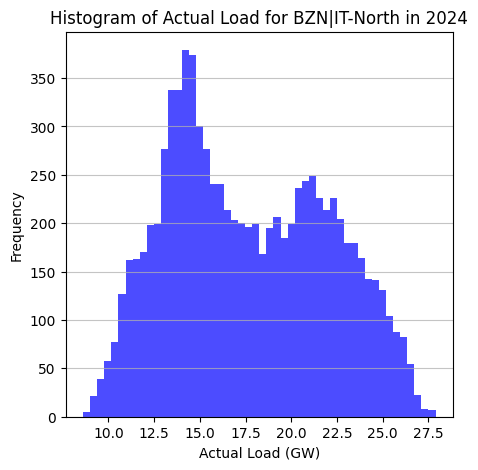

'Data for France (FR)'

'Mean load: 49.05 GW ± 9.83 GW'

'Variation (std/mean): 20.05%'

'Median load: 47.55 GW (Q1: 41.94 GW, Q3: 55.50 GW)'

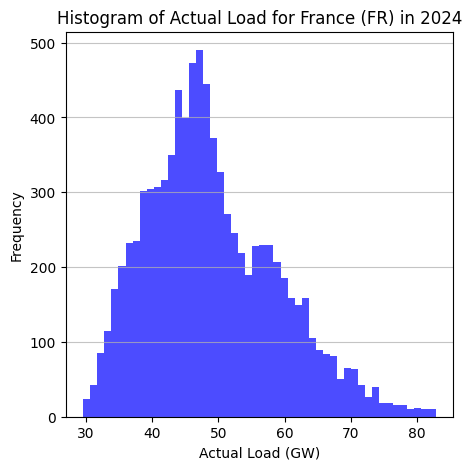

'Data for Poland (PL)'

'Mean load: 18.26 GW ± 3.05 GW'

'Variation (std/mean): 16.69%'

'Median load: 18.37 GW (Q1: 15.68 GW, Q3: 20.50 GW)'

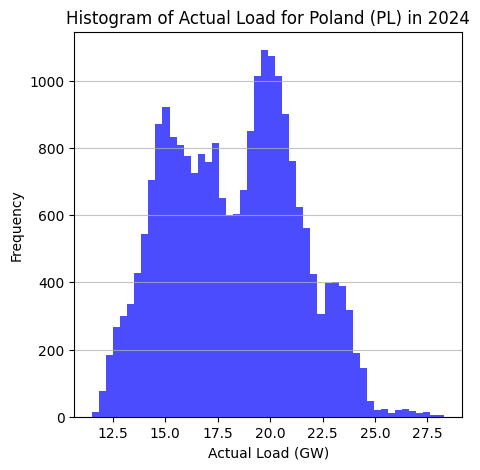

'Data for Switzerland (CH)'

'Mean load: 6.79 GW ± 1.12 GW'

'Variation (std/mean): 16.52%'

'Median load: 6.81 GW (Q1: 6.02 GW, Q3: 7.56 GW)'

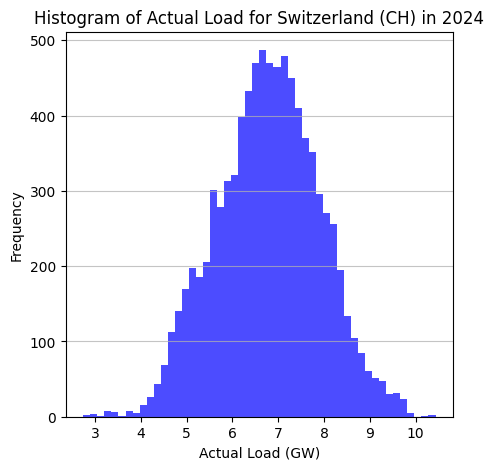

In [ ]:
for country in countries:
    # Load the data
    data_file = os.path.join(total_loads_path, f"Total_Load_Actual_{country}_2024.csv")
    df = pd.read_csv(data_file, parse_dates=["DateTime (UTC)"])
    df.set_index("DateTime (UTC)", inplace=True)
    
    # Convert to MWh (hourly resolution)
    df["Actual Load"] = df["Actual Load"] * 1
    
    # Plot an histogram of the load values
    plt.figure(figsize=(5, 5))
    plt.hist(df["Actual Load"]/1000, bins=50, color='blue', alpha=0.7)
    plt.title(f'Histogram of Actual Load for {country} in 2024')
    plt.xlabel('Actual Load (GW)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.savefig(f'./Total Loads/{country}_load_histogram_2024.pdf', bbox_inches='tight')
    plt.show()

## Border Flows

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math

In [18]:
# Import flows from csv files
countries = ["IT", "PO", "CH", "FR"]
filenames = [f"./Border Flows/{country}_net_flow_2024.csv" for country in countries]
dfs = [pd.read_csv(filename, parse_dates=["timestamp"]) for filename in filenames]
# Combine into a single DataFrame with columns for each country
combined_df = pd.DataFrame({"timestamp": dfs[0]["timestamp"]})
for country, df in zip(countries, dfs):
    combined_df[country] = df["flow_mw"]

print(combined_df.head())

                  timestamp      IT      PO      CH       FR
0 2023-01-01 00:00:00+00:00 -3116.0  1082.0 -8430.0   5674.0
1 2023-01-01 00:15:00+00:00 -3036.0  1397.0  1116.0   6973.0
2 2023-01-01 00:30:00+00:00 -2822.0  1592.0   301.0   8730.0
3 2023-01-01 00:45:00+00:00 -3235.0  1779.0   417.0  26949.0
4 2023-01-01 01:00:00+00:00 -3121.0  1417.0 -8187.0  45428.0


In [ ]:
for country in countries:
    # Load the data
    data_file = os.path.join(border_flows_path, f"Net_Border_Flows_{country}_2024.csv")
    df = pd.read_csv(data_file, parse_dates=["DateTime (UTC)"])
    df.set_index("DateTime (UTC)", inplace=True)
    
    # Convert to MWh (hourly resolution)
    df["Net Border Flows"] = df["Net Border Flows"] * 1
    
    # Plot the histogram
    plt.figure(figsize=(5, 5))
    plt.hist(df["Net Border Flows"], bins=100, color='red', alpha=0.7, label=country)
    plt.xlabel("Net Border Flows (MW)")
    plt.ylabel("Frequency")
    plt.ylim(0.9, 1e4)
    plt.xlim(-6e4, 6e4)
    plt.title("Histogram of Net Border Flows (2024)")
    plt.yscale('log')
    plt.legend()
    plt.vlines(0, 0, 1e4, colors='k', linestyles='dashed')
    plt.savefig(f'./Border Flows/Net_Border_Flows_Histogram_2024_{country}.pdf', bbox_inches='tight')
    plt.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

---


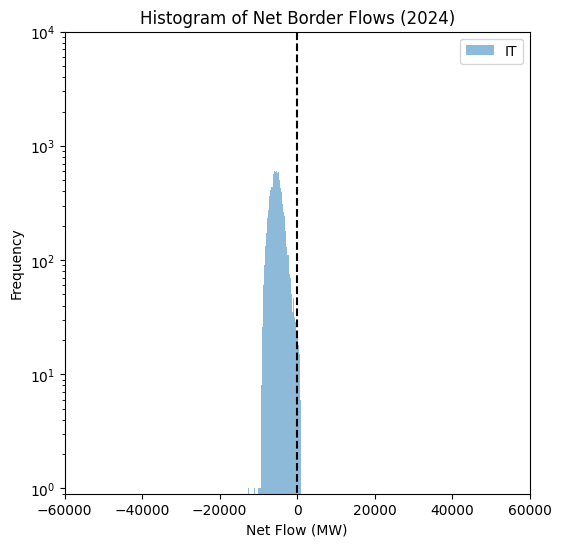

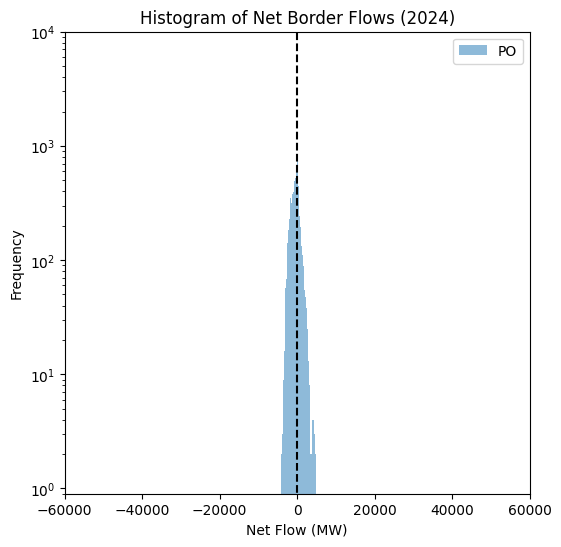

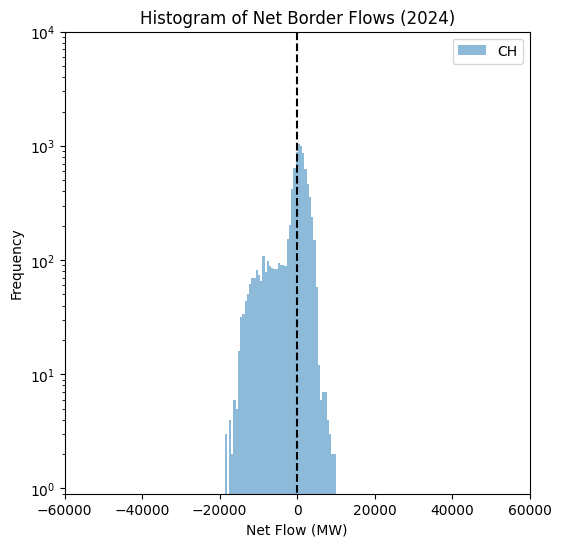

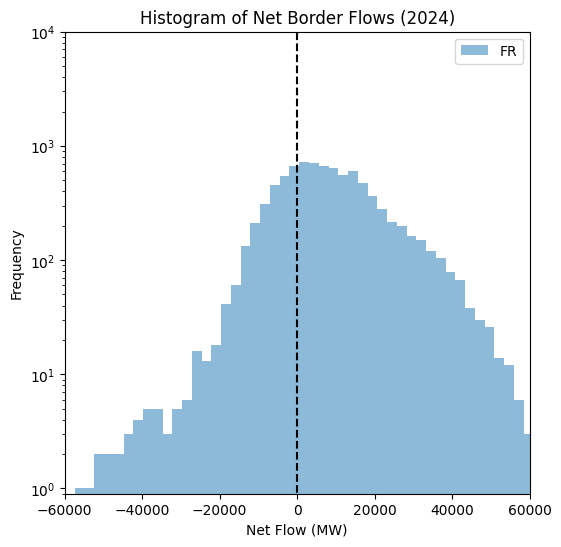

In [20]:
for country in countries:
    plt.figure(figsize=(6, 6))
    plt.hist(combined_df[country], bins=50, alpha=0.5, label=country)
    plt.xlabel("Net Flow (MW)")
    plt.ylabel("Frequency")
    plt.ylim(0.9, 1e4)
    plt.xlim(-6e4, 6e4)
    plt.title("Histogram of Net Border Flows (2024)")
    plt.yscale('log')
    plt.legend()
    plt.vlines(0, 0, 1e4, colors='k', linestyles='dashed')
    plt.savefig(f'./Border Flows/Net_Border_Flows_Histogram_2024_{country}.png')
    plt.show()

## Others

### Population of north bidding zone of Italy
Information used in the thesis for reference

In [21]:
#import Popolazione residente.csv
import pandas as pd
df = pd.read_csv('Popolazione residente.csv', sep=',')
north_bidding_zone =["Piemonte", "Lombardia", "Veneto", "Friuli Venezia Giulia", "Trentino Alto Adige", "Emilia Romagna", "Valle d'Aosta", "Liguria"]
print(len(north_bidding_zone))
total_population = df["Totale"].sum()
north_population = df[df["Regione"].isin(north_bidding_zone)]["Totale"].sum()
north_population_percentage = (north_population / total_population) * 100
print(f"Total Population: {total_population}")  
print(f"North Population: {north_population}")
print(f"North Population Percentage: {north_population_percentage:.2f}%")

8
Total Population: 58971230
North Population: 20625033
North Population Percentage: 34.97%
